<a href="https://colab.research.google.com/github/srishtysharma0707-glitch/Expense-Tracker/blob/main/Home_Loan_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
#import Data Set
import pandas as pd

df = pd.read_csv("loan_data.csv")

print(df.shape)
df.head()

(9578, 14)


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [7]:
# Check Null Values
df.isnull().sum()

,0
credit.policy,0
purpose,0
int.rate,0
installment,0
log.annual.inc,0
dti,0
fico,0
days.with.cr.line,0
revol.bal,0
revol.util,0


In [8]:
#Check total missing values:
print(df.isnull().sum().sum())

0


In [ ]:
#Print Percentage of Defaulters and Payers
target_percent = (
    df['not.fully.paid']
    .value_counts(normalize=True)*100
)

print(target_percent)

In [11]:
#Balance Dataset
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

le = LabelEncoder()

df['purpose'] = le.fit_transform(df['purpose'])

X = df.drop('not.fully.paid', axis=1)
y = df['not.fully.paid']

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

print(y_resampled.value_counts())

not.fully.paid
0    8045
1    8045
Name: count, dtype: int64


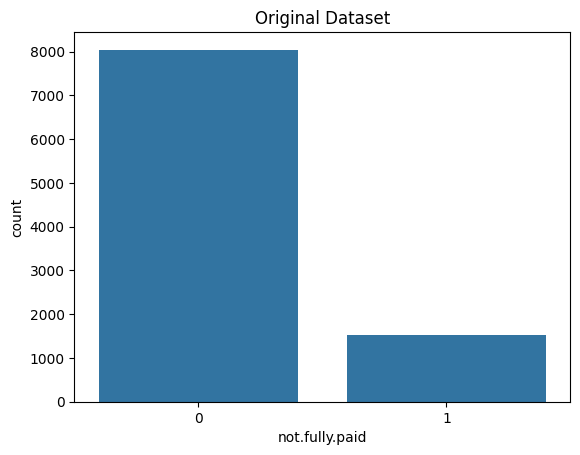

In [12]:
# Plot Imbalanced and Balanced Data
#Before Balancing
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y)

plt.title("Original Dataset")
plt.show()

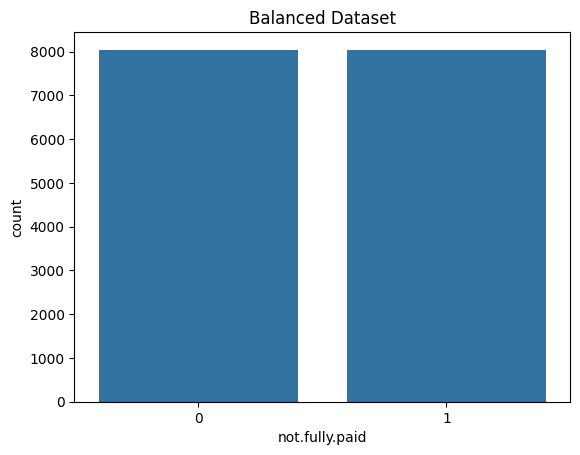

In [13]:
#After Balancing
sns.countplot(x=y_resampled)

plt.title("Balanced Dataset")
plt.show()

In [15]:
# Encode Required Columns

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['purpose'] = encoder.fit_transform(df['purpose'])

In [19]:
#Train-Test Split and Scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
#Build Deep Learning Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()

model.add(Dense(64,
                activation='relu',
                input_shape=(X_train.shape[1],)))

model.add(Dropout(0.3))

model.add(Dense(32,
                activation='relu'))

model.add(Dropout(0.3))

model.add(Dense(16,
                activation='relu'))

model.add(Dense(1,
                activation='sigmoid'))

#Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
#Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6255 - loss: 0.6429 - val_accuracy: 0.6769 - val_loss: 0.5873
Epoch 2/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6626 - loss: 0.6081 - val_accuracy: 0.6816 - val_loss: 0.5770
Epoch 3/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6743 - loss: 0.5959 - val_accuracy: 0.6784 - val_loss: 0.5697
Epoch 4/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6760 - loss: 0.5909 - val_accuracy: 0.6835 - val_loss: 0.5669
Epoch 5/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6821 - loss: 0.5887 - val_accuracy: 0.6920 - val_loss: 0.5595
Epoch 6/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6867 - loss: 0.5856 - val_accuracy: 0.6948 - val_loss: 0.5622
Epoch 7/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6875 - loss: 0.5826 - val_accuracy: 0.6990 - val_loss: 0.5545
Epoch 8/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6898 - loss: 0.5775 - val_accuracy: 0.

In [23]:
#Predict
y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [24]:
#Calculate Sensitivity
from sklearn.metrics import recall_score

sensitivity = recall_score(
    y_test,
    y_pred
)

print("Sensitivity:", sensitivity)

#Sensitivity=TP/TP + FNT

Sensitivity: 0.7356608478802993


In [25]:
#Calculate ROC-AUC
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    y_test,
    y_pred_prob
)

print("ROC-AUC:", auc)

ROC-AUC: 0.794477367609477


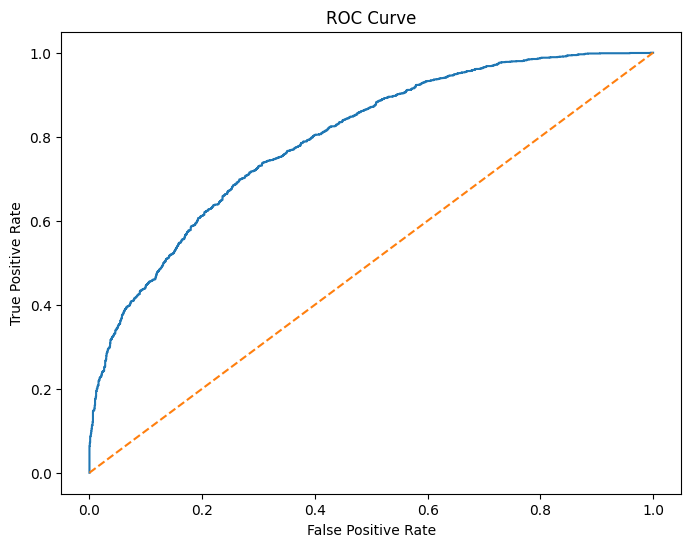

In [26]:
#Plot ROC Curve
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_pred_prob
)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve')

plt.show()

In [27]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[1120  494]
 [ 424 1180]]
